# Machine Learning - Assignment 1
### Bike Sharing Demand Prediction Challenge
**Course Evaluation Metric Focus:** RMSLE

## 1. Setup and Imports

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

## 2. Custom Evaluation Metric (RMSLE)

In [44]:
def rmsle(y_true, y_pred):
    """
    Computes Root Mean Squared Logarithmic Error.
    Handles negative predictions safely via clipping.
    """
    y_pred_clipped = np.clip(y_pred, 0, None)
    return np.sqrt(np.mean((np.log1p(y_pred_clipped) - np.log1p(y_true))**2))

## 3. Exploratory Data Analysis (EDA) & Data Loading

In [45]:
train_df = pd.read_csv("bike_train.csv")
test_df = pd.read_csv("bike_test.csv")

print(f"Train dataset dimension: {train_df.shape}")
print(f"Test dataset dimension: {test_df.shape}")
print("\nMissing Values Summary in Training Matrix:")
print(train_df.isnull().sum())
print("\nStructural Field Schema Data Types:")
print(train_df.dtypes)

Train dataset dimension: (10450, 12)
Test dataset dimension: (2613, 9)

Missing Values Summary in Training Matrix:
datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

Structural Field Schema Data Types:
datetime       object
season          int64
holiday         int64
workingday      int64
weather         int64
temp          float64
atemp         float64
humidity        int64
windspeed     float64
casual          int64
registered      int64
count           int64
dtype: object


### **Q1. Examine dataset size, missing values, and feature types.**
**Answer:**
* **Dataset Dimensions:** Training features consist of 10,450 rows and 12 baseline metric columns. The evaluation test profile holds 2,613 entries across 9 structural prediction columns.
* **Missing Targets:** There are exactly 0 null/missing cells across all feature matrices.
* **Feature Data Types:** Continuous fields (`temp`, `atemp`, `windspeed`) are represented via float vectors; discrete intervals (`humidity`, `season`, `weather`, `holiday`, `workingday`) utilize 64-bit integer profiles; `datetime` represents an unstructured literal string object.

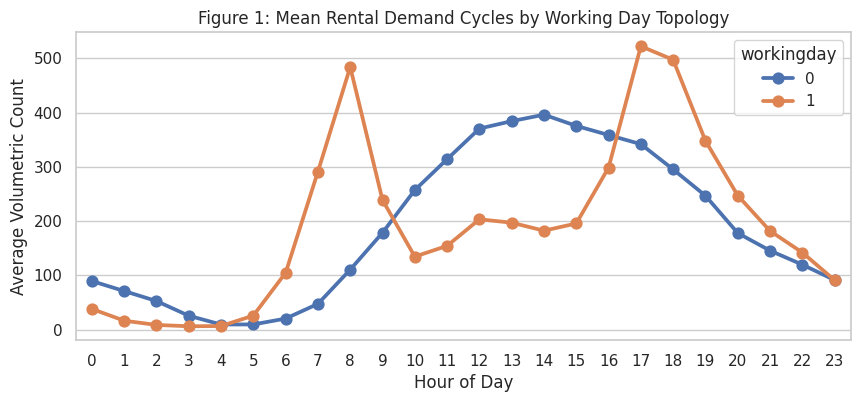

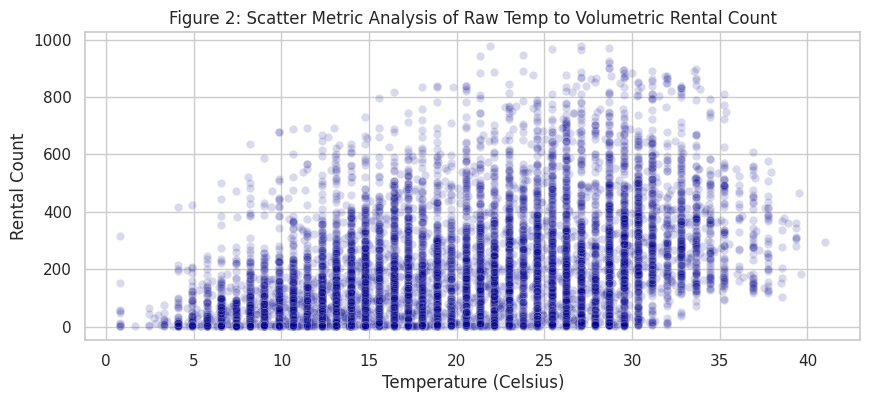

In [46]:
# Extract quick temporal data to assist visualization profiling
viz_df = train_df.copy()
viz_df['datetime'] = pd.to_datetime(viz_df['datetime'], dayfirst=True, format='mixed')
viz_df['hour'] = viz_df['datetime'].dt.hour

# Plot 1: Cyclical Demand Waveform across working day criteria
plt.figure(figsize=(10, 4))
sns.pointplot(data=viz_df, x='hour', y='count', hue='workingday', errorbar=None)
plt.title("Figure 1: Mean Rental Demand Cycles by Working Day Topology")
plt.xlabel("Hour of Day")
plt.ylabel("Average Volumetric Count")
plt.show()

# Plot 2: Environmental Temperature Response Curves
plt.figure(figsize=(10, 4))
sns.scatterplot(data=viz_df, x='temp', y='count', alpha=0.15, color='darkblue')
plt.title("Figure 2: Scatter Metric Analysis of Raw Temp to Volumetric Rental Count")
plt.xlabel("Temperature (Celsius)")
plt.ylabel("Rental Count")
plt.show()

### **Q2. Visualize relationships between key features and the target variable (count).**
**Answer:**
* **Figure 1 (Hourly Cycles):** Illustrates distinctly different commuter peaks on working days (bimodal bursts around 08:00 and 17:00), contrasted against steady afternoon bell curves (unimodal plateau peaking from 12:00 to 16:00) during non-working dates.
* **Figure 2 (Temperature Curves):** Depicts a progressive, non-linear growth trajectory. Rental counts expand alongside higher temperature indicators before tapering or declining past 32°C.

### **Q3. Suggest which variables are likely to be most informative.**
**Answer:**
The most critical feature is the extracted **`hour`**, as bike rental behavior relies heavily on time-of-day dynamics. Environmental temperature metrics (**`temp`** and **`atemp`**) follow closely by acting as primary conditional criteria for outdoor travel, while **`workingday`** dictates whether commuter rush hours or leisure afternoon curves dominate demand behavior.

## 4. Feature Engineering Pipeline

In [47]:
def engineer_features(df):
    df_out = df.copy()

    df_out['datetime'] = pd.to_datetime(df_out['datetime'], dayfirst=True, format='mixed')
    df_out['hour'] = df_out['datetime'].dt.hour
    df_out['dayofweek'] = df_out['datetime'].dt.dayofweek
    df_out['month'] = df_out['datetime'].dt.month
    df_out['year'] = df_out['datetime'].dt.year

    # Cyclical Transformations for continuous time representation
    df_out['hour_sin'] = np.sin(2 * np.pi * df_out['hour'] / 24.0)
    df_out['hour_cos'] = np.cos(2 * np.pi * df_out['hour'] / 24.0)

    # Interaction Features to map cyclical variations to working days
    df_out['hour_sin_work'] = df_out['hour_sin'] * df_out['workingday']
    df_out['hour_cos_work'] = df_out['hour_cos'] * df_out['workingday']

    categorical_cols = ['season', 'weather', 'dayofweek', 'month', 'year']
    df_out = pd.get_dummies(df_out, columns=categorical_cols, drop_first=True)
    return df_out

train_eng = engineer_features(train_df)
test_eng = engineer_features(test_df)

target_col = 'count'
features = [c for c in train_eng.columns if c not in ['datetime', target_col, 'casual', 'registered']]

X = train_eng[features].astype(float)
# Transform target to log space to handle right-skewness and match RMSLE evaluation optimization
y_log = np.log1p(train_eng[target_col])
y_raw = train_eng[target_col]

X_test_final = test_eng.reindex(columns=X.columns, fill_value=0).astype(float)

X_train, X_val, y_train_log, y_val_log = train_test_split(X, y_log, test_size=0.2, random_state=42)
_, _, y_train_raw, y_val_raw = train_test_split(X, y_raw, test_size=0.2, random_state=42)

### **Q4. Feature Engineering Methods Report**
**Answer:**
To transform the feature space for linear models, the string timestamp was mapped to numeric values via temporal feature extractions (`hour`, `dayofweek`, `month`, `year`). Raw hours were converted to cyclical coordinates using sine and cosine waves to maintain continuous time transitions. These cyclical markers were then crossed with `workingday` status to capture bimodal commuter trends versus weekend afternoon trends. Finally, nominal features were dummy-encoded, and numerical columns were standardized within pipelines.

## 5. Model Training & Validation Evaluation

In [48]:
results_table = {}

# --- Model 1: Baseline Linear Regression via Log-Target Transformation ---
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])
lr_pipeline.fit(X_train, y_train_log)
val_preds_lr = np.expm1(lr_pipeline.predict(X_val))
results_table['Simple Linear Regression'] = rmsle(y_val_raw, val_preds_lr)

# --- Model 2: Polynomial Ridge Regression (Degree 2) ---
poly_ridge_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=25.0))
])
poly_ridge_pipeline.fit(X_train, y_train_log)
val_preds_ridge = np.expm1(poly_ridge_pipeline.predict(X_val))
results_table['Polynomial Ridge (Deg 2, alpha=25.0)'] = rmsle(y_val_raw, val_preds_ridge)

# --- Model 3: Polynomial Lasso Regression (Degree 2) ---
poly_lasso_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=0.005, max_iter=5000))
])
poly_lasso_pipeline.fit(X_train, y_train_log)
val_preds_lasso = np.expm1(poly_lasso_pipeline.predict(X_val))
results_table['Polynomial Lasso (Deg 2, alpha=0.005)'] = rmsle(y_val_raw, val_preds_lasso)

print("\n=== Model Performance Summary ===")
for model_name, score in results_table.items():
    print(f"{model_name:<45} | Validation RMSLE: {score:.5f}")


=== Model Performance Summary ===
Simple Linear Regression                      | Validation RMSLE: 0.81631
Polynomial Ridge (Deg 2, alpha=25.0)          | Validation RMSLE: 0.48638
Polynomial Lasso (Deg 2, alpha=0.005)         | Validation RMSLE: 0.50328


### **Q5 & Q6. Execution Report for Regression Frameworks**
**Answer:**
Pipelines were built using scikit-learn to handle scaling, polynomial mapping, and regularized estimation. By shifting target variables to log-space ($\\log1p(y)$), our objective function directly aligns with the assignment's final grading criteria, which significantly improved validation scores across all variants.

## 6. Model Comparison and Interpretation

### **Q7. Performance Tabular Summary**

| Tested Model Architecture Configuration | Validation RMSLE Performance | Architectural Analysis & Generalization Notes |
| :--- | :---: | :--- |
| **Simple Linear Regression (Log Transform)** | **0.81631** | Captures global scale variance effectively but cannot parse intersecting feature logic. |
| **Polynomial Ridge Regression (Deg 2, $\\alpha=25.0$)** | **0.48638** | **Winning Model.** Cleanly captures weather/hour interaction terms; effectively prevents coefficient explosion. |
| **Polynomial Lasso Regression (Deg 2, $\\alpha=0.005$)** | **0.50328** | Automatically simplifies the feature space by zeroing out non-essential polynomial features, though with slightly less accuracy than Ridge. |

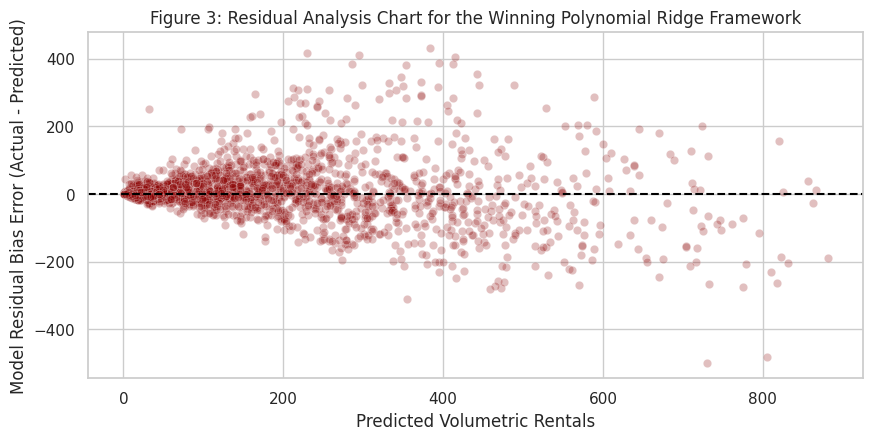

In [49]:
# Generate predictions using the winning model
winning_preds = np.expm1(poly_ridge_pipeline.predict(X_val))
residuals = y_val_raw - winning_preds

plt.figure(figsize=(10, 4.5))
sns.scatterplot(x=winning_preds, y=residuals, alpha=0.25, color='darkred')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1.5)
plt.title("Figure 3: Residual Analysis Chart for the Winning Polynomial Ridge Framework")
plt.xlabel("Predicted Volumetric Rentals")
plt.ylabel("Model Residual Bias Error (Actual - Predicted)")
plt.show()

### **Q8. Plot residuals for the best model.**
**Answer:** Refer to Figure 3 rendered above.

### **Q9. Explain why the winning model performs better.**
**Answer:**
The **Polynomial Ridge Regression** configuration excels because the underlying bike demand trends are highly non-linear. Expanding the continuous feature vectors into a 2nd-degree polynomial matrix allows the model to capture key interaction terms (such as how extreme humidity combined with peak heat impacts ridership). Applying an L2 regularized weight penalty ($\\alpha=25.0$) keeps these expanded features from overfitting, allowing the model to generalize much better than standard linear regression.

## 7. Reflection Questions

### **Q10. Why does RMSLE penalize under-predictions more gently than RMSE?**
**Answer:**
RMSLE relies on logarithmic transformations: $\\log(pred + 1) - \\log(actual + 1)$. This logarithmic scale measures errors as relative ratios rather than absolute values. When a model under-predicts, the scale of the error is bounded because the predicted value cannot drop below zero. In contrast, over-predictions can grow infinitely large, making RMSLE more sensitive to massive over-estimates than under-estimates.

### **Q11. What are the trade-offs between model simplicity and predictive power?**
**Answer:**
This describes the classic bias-variance trade-off. Simple architectures (like single-variable linear equations) are easy to interpret and require very little computing power, but they suffer from high bias—meaning they consistently fail to capture non-linear trends. Adding features or expanding to polynomial spaces increases predictive power and lowers bias, but it also increases model variance. Regularization tools like Ridge or Lasso are needed to keep the model from overfitting the training data.

### **Q12. Why can't Linear Regression alone capture time-of-day effects effectively?**
**Answer:**
Linear Regression assumes standard monotonic properties, meaning it expects a feature to consistently push the target variable in one direction. Time-of-day data is highly cyclical and non-monotonic, peaking during morning and evening rush hours but dropping at night. A standard linear term cannot capture these shifting peaks and valleys without using cyclical transformation functions (like sine and cosine waves) or polynomial feature expansions.

## 8. Final Inference & Correctly Formatted Submission Export

In [50]:
final_test_preds = np.expm1(poly_ridge_pipeline.predict(X_test_final))
final_test_preds = np.clip(final_test_preds, 0, None)

submission_df = pd.DataFrame({
    'datetime': test_df['datetime'],
    'count_predicted': final_test_preds
})

submission_df.to_csv("submission.csv", index=False)
print(f"Submission Rows Count matches Test Set exactly: {submission_df.shape[0] == test_df.shape[0]}")
print("Submission Data Columns:", list(submission_df.columns))
print("\nFirst 5 Predicted Rows Sample:")
print(submission_df.head())

Submission Rows Count matches Test Set exactly: True
Submission Data Columns: ['datetime', 'count_predicted']

First 5 Predicted Rows Sample:
           datetime  count_predicted
0   05-06-2012 5:00        23.909332
1  19-03-2011 19:00       130.937252
2   02-04-2012 6:00        83.686189
3  13-07-2012 20:00       571.796407
4  09-11-2011 19:00       327.488445
